# CHIRPS Rainfall Data Collection

This notebook prepares the rainfall data collection stage for the Drought & Food Security Early Warning System project.

Rainfall is an important predictor because poor rainfall can reduce crop production, pasture availability, water access, and livestock health. These factors can increase food insecurity risk in Kenya's ASAL counties.

Main goals:
1. Identify the rainfall data source
2. Define the target counties and time period
3. Plan how rainfall data will be aggregated by county
4. Prepare rainfall features for future merging with IPC food insecurity data

## Rainfall Dataset Source

The rainfall predictor will use CHIRPS rainfall data.

CHIRPS stands for Climate Hazards Group InfraRed Precipitation with Station data. It provides rainfall estimates that are widely used in drought monitoring, food security analysis, and climate-risk projects.

For this project, rainfall data will be collected for Kenya's target counties and aggregated into monthly or seasonal county-level rainfall features.

Planned source:
- Dataset: CHIRPS Rainfall
- Provider: Climate Hazards Center, UC Santa Barbara
- Time coverage: 1981 to present
- Spatial resolution: approximately 0.05 degrees
- Planned use: county-level rainfall totals and rainfall anomaly features

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
IPC_PATH = Path("../02_data/processed/ipc_max_phase_per_county.csv")

ipc_df = pd.read_csv(IPC_PATH)
ipc_df["date"] = pd.to_datetime(ipc_df["date"])

print("Rows and columns:", ipc_df.shape)
ipc_df.head()

Rows and columns: (322, 7)


,date,analysis_period,county,max_ipc_phase,phase_3_plus_population,total_population,phase_3_plus_percentage
0,2019-07-01,Jul 2019,Baringo,4,105555,703697,0.15
1,2019-07-01,Jul 2019,Embu,3,32883,219220,0.15
2,2019-07-01,Jul 2019,Garissa,4,151183,431950,0.35
3,2019-07-01,Jul 2019,Isiolo,4,54413,155465,0.35
4,2019-07-01,Jul 2019,Kajiado,3,43536,870721,0.05


In [3]:
target_counties = sorted(ipc_df["county"].unique())

print("Number of target counties:", len(target_counties))
target_counties

Number of target counties: 23


['Baringo',
 'Embu',
 'Garissa',
 'Isiolo',
 'Kajiado',
 'Kilifi',
 'Kitui',
 'Kwale',
 'Laikipia',
 'Lamu',
 'Makueni',
 'Mandera',
 'Marsabit',
 'Meru',
 'Narok',
 'Nyeri',
 'Samburu',
 'Taita Taveta',
 'Tana River',
 'Tharaka Nithi',
 'Turkana',
 'Wajir',
 'West Pokot']

In [4]:
print("Start date:", ipc_df["date"].min())
print("End date:", ipc_df["date"].max())

ipc_df["analysis_period"].unique()

Start date: 2019-07-01 00:00:00
End date: 2026-02-01 00:00:00


<StringArray>
['Jul 2019', 'Feb 2020', 'Aug 2020', 'Feb 2021', 'Jul 2021', 'Feb 2022',
 'Jul 2022', 'Jan 2023', 'Jul 2023', 'Feb 2024', 'Jul 2024', 'Feb 2025',
 'Jul 2025', 'Feb 2026']
Length: 14, dtype: str

## Planned Rainfall Feature Engineering

The IPC dataset is available by analysis period, such as Jul 2019, Feb 2020, and Jan 2023. Rainfall must be converted into features that can help explain food insecurity conditions before each IPC period.

Planned rainfall features:
- 1-month rainfall before IPC analysis date
- 3-month cumulative rainfall before IPC analysis date
- 6-month cumulative rainfall before IPC analysis date
- Rainfall anomaly compared with long-term average
- Seasonal rainfall indicators for Kenya's main rainy seasons

These features will later be merged with the IPC county-level dataset using `county` and `date`.

In [5]:
RAINFALL_OUTPUT_PATH = Path("../02_data/processed/county_rainfall_features.csv")

print("Planned rainfall output path:")
print(RAINFALL_OUTPUT_PATH)

Planned rainfall output path:
..\02_data\processed\county_rainfall_features.csv


## Test Reading CHIRPS Raster Files

The CHIRPS rainfall files are GeoTIFF raster files. Each file represents rainfall for one month. Before downloading more rainfall data, we first test whether Python can read one file successfully.

In [6]:
import sys

!{sys.executable} -m pip install rasterio

In [7]:
import rasterio
from pathlib import Path

CHIRPS_DIR = Path("../02_data/raw/chirps")

chirps_files = sorted(CHIRPS_DIR.glob("*.tif*"))

print("Number of CHIRPS files found:", len(chirps_files))

for file in chirps_files:
    print(file.name)

Number of CHIRPS files found: 6
chirps-v2.0.2020.12.tif
chirps-v2.0.2020.12.tif.gz
chirps-v2.0.2022.12.tif
chirps-v2.0.2022.12.tif.gz
chirps-v2.0.2023.01.tif
chirps-v2.0.2023.01.tif.gz


### File Format Issue

The CHIRPS files were downloaded as `.tif.gz` files. This means the GeoTIFF rainfall map is compressed. Before reading the file with `rasterio`, the `.gz` file must be extracted into a normal `.tif` file.

In [8]:
from pathlib import Path
import rasterio

CHIRPS_DIR = Path("../02_data/raw/chirps")

tif_files = sorted(CHIRPS_DIR.glob("*.tif"))

print("Extracted TIFF files found:", len(tif_files))

for file in tif_files:
    print(file.name)

Extracted TIFF files found: 3
chirps-v2.0.2020.12.tif
chirps-v2.0.2022.12.tif
chirps-v2.0.2023.01.tif


In [9]:
test_file = tif_files[-1]

print("Testing file:", test_file.name)

with rasterio.open(test_file) as src:
    print("File opened successfully")
    print("Width:", src.width)
    print("Height:", src.height)
    print("Number of bands:", src.count)
    print("Coordinate reference system:", src.crs)
    print("Bounds:", src.bounds)

Testing file: chirps-v2.0.2023.01.tif
File opened successfully
Width: 1500
Height: 1600
Number of bands: 1
Coordinate reference system: EPSG:4326
Bounds: BoundingBox(left=-20.0, bottom=-40.000001192092896, right=55.00000111758709, top=40.0)


## CHIRPS Raster File Inspection Result

The CHIRPS rainfall file was opened successfully with `rasterio`. The test file used was `chirps-v2.0.2023.01.tif`, which represents rainfall for **January 2023**. The website date shows when the file was uploaded or modified, not the rainfall month.

The file is a raster map with 1500 columns, 1600 rows, and 1 band. This means it is a grid of pixels, where each pixel stores one rainfall value for January 2023.

The file uses the `EPSG:4326` coordinate system, which means it uses latitude and longitude. Its bounds cover a wide Africa region from about longitude -20 to 55 and latitude -40 to 40. Kenya falls inside this area, so this file can be used for Kenya rainfall analysis.

The first rainfall summary showed a minimum value of `-9999`. This is not real rainfall. It is a NoData value, meaning some pixels do not contain valid rainfall data. Because the first average calculation included these `-9999` values, the average rainfall became negative and inaccurate.

Before calculating rainfall statistics, the NoData value must be replaced with `NaN` so Python can ignore missing pixels.

In [10]:
import numpy as np

with rasterio.open(test_file) as src:
    rainfall = src.read(1)
    nodata_value = src.nodata

print("NoData value:", nodata_value)

rainfall_clean = np.where(rainfall == nodata_value, np.nan, rainfall)

print("Clean minimum rainfall:", np.nanmin(rainfall_clean))
print("Clean maximum rainfall:", np.nanmax(rainfall_clean))
print("Clean average rainfall:", np.nanmean(rainfall_clean))

NoData value: None
Clean minimum rainfall: -9999.0
Clean maximum rainfall: 962.84265
Clean average rainfall: -4816.566


### NoData Metadata Issue

The raster file contains `-9999` values, but `rasterio` does not detect an official NoData value from the file metadata. Because of this, `src.nodata` returns `None`.

To fix this, we manually treat `-9999` as the missing-data value and replace it with `NaN` before calculating rainfall statistics.

In [11]:
import numpy as np

with rasterio.open(test_file) as src:
    rainfall = src.read(1)

# CHIRPS uses -9999 as missing/no-data value in this file
rainfall_clean = np.where(rainfall == -9999, np.nan, rainfall)

print("Clean minimum rainfall:", np.nanmin(rainfall_clean))
print("Clean maximum rainfall:", np.nanmax(rainfall_clean))
print("Clean average rainfall:", np.nanmean(rainfall_clean))

Clean minimum rainfall: 0.0
Clean maximum rainfall: 962.84265
Clean average rainfall: 50.912693


### Clean Rainfall Summary Result

After manually replacing `-9999` NoData values with `NaN`, the rainfall statistics became realistic. The clean minimum rainfall is `0.0`, meaning some valid pixels had no rainfall. The clean average rainfall is approximately `50.9 mm` across the valid pixels in the Africa raster.

This confirms that the CHIRPS raster file can be read and cleaned correctly. However, this summary is for the full raster area, not Kenya counties only. The next step is to use Kenya county boundary data to calculate county-level rainfall values.

## Next Step: Move from Raster-Level Rainfall to County-Level Rainfall

So far, the rainfall file has only been checked at the raster level. This means we confirmed that the CHIRPS rainfall file can be opened, cleaned, and summarized correctly.

However, the project needs county-level rainfall values so that rainfall can later be joined with the IPC county-level food insecurity dataset.

The next step is to use Kenya county boundary data and calculate average rainfall for each county. This process is called spatial aggregation or zonal statistics.

In [12]:
import geopandas as gpd
from pathlib import Path

BOUNDARY_PATH = Path("../02_data/raw/ken_admin1.geojson")

counties = gpd.read_file(BOUNDARY_PATH)

print("Rows and columns:", counties.shape)
counties.head()

Rows and columns: (47, 22)


,adm1_name,adm1_name1,adm1_name2,adm1_name3,adm1_pcode,adm0_name,adm0_name1,adm0_name2,adm0_name3,adm0_pcode,...,area_sqkm,cod_version,lang,lang1,lang2,lang3,adm1_ref_name,center_lat,center_lon,geometry
0,Baringo,None,None,None,KE030,Kenya,None,None,None,KE,...,10889.239313,V_01,en,None,None,None,Baringo,0.726352,36.018591,"POLYGON ((35.7839 1.65557, 35.78298 1.65589, 3..."
1,Bomet,None,None,None,KE036,Kenya,None,None,None,KE,...,2438.219727,V_01,en,None,None,None,Bomet,-0.716095,35.238459,"POLYGON ((35.4736 -0.3992, 35.47264 -0.39949, ..."
2,Bungoma,None,None,None,KE039,Kenya,None,None,None,KE,...,3016.174229,V_01,en,None,None,None,Bungoma,0.785694,34.718757,"POLYGON ((34.62017 1.10228, 34.61953 1.10287, ..."
3,Busia,None,None,None,KE040,Kenya,None,None,None,KE,...,1811.571693,V_01,en,None,None,None,Busia,0.375707,34.265111,"POLYGON ((34.36097 0.7773, 34.3602 0.77807, 34..."
4,Elgeyo-Marakwet,None,None,None,KE028,Kenya,None,None,None,KE,...,3008.391184,V_01,en,None,None,None,Elgeyo-Marakwet,0.745102,35.560856,"POLYGON ((35.69818 1.28225, 35.69663 1.28415, ..."


## County Boundary File Loaded Successfully

The Kenya county boundary file was loaded successfully from `ken_admin1.geojson`.

The file contains 47 rows, representing Kenya's 47 counties, and 22 columns containing administrative attributes and geometry data.

The county name column is `adm1_name`. This column will be used to match boundary records with the cleaned IPC dataset county names.

In [13]:
counties.columns.tolist()

['adm1_name',
 'adm1_name1',
 'adm1_name2',
 'adm1_name3',
 'adm1_pcode',
 'adm0_name',
 'adm0_name1',
 'adm0_name2',
 'adm0_name3',
 'adm0_pcode',
 'valid_on',
 'valid_to',
 'area_sqkm',
 'cod_version',
 'lang',
 'lang1',
 'lang2',
 'lang3',
 'adm1_ref_name',
 'center_lat',
 'center_lon',
 'geometry']

In [14]:
counties[["adm1_name", "adm1_pcode"]].head(10)

,adm1_name,adm1_pcode
0,Baringo,KE030
1,Bomet,KE036
2,Bungoma,KE039
3,Busia,KE040
4,Elgeyo-Marakwet,KE028
5,Embu,KE014
6,Garissa,KE007
7,Homa Bay,KE043
8,Isiolo,KE011
9,Kajiado,KE034


## Filter Boundary File to Target Counties

The boundary file contains all 47 Kenya counties. For this project, we only need the 23 target counties used in the processed IPC dataset. This step filters the boundary file so it can later be used for county-level maps and rainfall aggregation.

In [15]:
target_counties = [
    "Baringo",
    "Embu",
    "Garissa",
    "Isiolo",
    "Kajiado",
    "Kilifi",
    "Kitui",
    "Kwale",
    "Laikipia",
    "Lamu",
    "Makueni",
    "Mandera",
    "Marsabit",
    "Meru",
    "Narok",
    "Nyeri",
    "Samburu",
    "Taita Taveta",
    "Tana River",
    "Tharaka Nithi",
    "Turkana",
    "Wajir",
    "West Pokot"
]

target_boundaries = counties[counties["adm1_name"].isin(target_counties)].copy()

print("Target boundary shape:", target_boundaries.shape)
target_boundaries[["adm1_name", "adm1_pcode"]].sort_values("adm1_name")

Target boundary shape: (22, 22)


,adm1_name,adm1_pcode
0,Baringo,KE030
5,Embu,KE014
6,Garissa,KE007
8,Isiolo,KE011
9,Kajiado,KE034
13,Kilifi,KE003
17,Kitui,KE015
18,Kwale,KE002
19,Laikipia,KE031
20,Lamu,KE005


In [16]:
matched_counties = set(target_boundaries["adm1_name"])
expected_counties = set(target_counties)

missing_from_boundaries = sorted(expected_counties - matched_counties)

missing_from_boundaries

['Tharaka Nithi']

In [17]:
sorted(counties["adm1_name"].unique())

['Baringo',
 'Bomet',
 'Bungoma',
 'Busia',
 'Elgeyo-Marakwet',
 'Embu',
 'Garissa',
 'Homa Bay',
 'Isiolo',
 'Kajiado',
 'Kakamega',
 'Kericho',
 'Kiambu',
 'Kilifi',
 'Kirinyaga',
 'Kisii',
 'Kisumu',
 'Kitui',
 'Kwale',
 'Laikipia',
 'Lamu',
 'Machakos',
 'Makueni',
 'Mandera',
 'Marsabit',
 'Meru',
 'Migori',
 'Mombasa',
 "Murang'a",
 'Nairobi',
 'Nakuru',
 'Nandi',
 'Narok',
 'Nyamira',
 'Nyandarua',
 'Nyeri',
 'Samburu',
 'Siaya',
 'Taita Taveta',
 'Tana River',
 'Tharaka-Nithi',
 'Trans Nzoia',
 'Turkana',
 'Uasin Gishu',
 'Vihiga',
 'Wajir',
 'West Pokot']

## Standardize Boundary County Names

One county did not match because the boundary file uses `Tharaka-Nithi`, while the IPC dataset uses `Tharaka Nithi`.

To make the boundary data match the cleaned IPC dataset, a new `county` column is created from `adm1_name`.

In [18]:
counties["county"] = counties["adm1_name"].replace({
    "Tharaka-Nithi": "Tharaka Nithi"
})

target_boundaries = counties[counties["county"].isin(target_counties)].copy()

print("Target boundary shape:", target_boundaries.shape)

target_boundaries[["adm1_name", "county", "adm1_pcode"]].sort_values("county")

Target boundary shape: (23, 23)


,adm1_name,county,adm1_pcode
0,Baringo,Baringo,KE030
5,Embu,Embu,KE014
6,Garissa,Garissa,KE007
8,Isiolo,Isiolo,KE011
9,Kajiado,Kajiado,KE034
13,Kilifi,Kilifi,KE003
17,Kitui,Kitui,KE015
18,Kwale,Kwale,KE002
19,Laikipia,Laikipia,KE031
20,Lamu,Lamu,KE005


In [19]:
matched_counties = set(target_boundaries["county"])
expected_counties = set(target_counties)

missing_from_boundaries = sorted(expected_counties - matched_counties)

missing_from_boundaries

[]

## Save Processed Target County Boundaries

After standardizing county names and filtering the boundary file to the 23 target counties, the processed boundary file is saved to the `02_data/processed/` folder.

This file will be used later for:
- county-level rainfall aggregation
- IPC risk maps
- joining food insecurity data with geographic boundaries

In [20]:
PROCESSED_BOUNDARY_PATH = Path("../02_data/processed/kenya_target_counties.geojson")

target_boundaries.to_file(PROCESSED_BOUNDARY_PATH, driver="GeoJSON")

print(f"Saved processed boundary file to: {PROCESSED_BOUNDARY_PATH}")

Saved processed boundary file to: ..\02_data\processed\kenya_target_counties.geojson


In [21]:
PROCESSED_BOUNDARY_PATH.exists()

True

<Axes: >

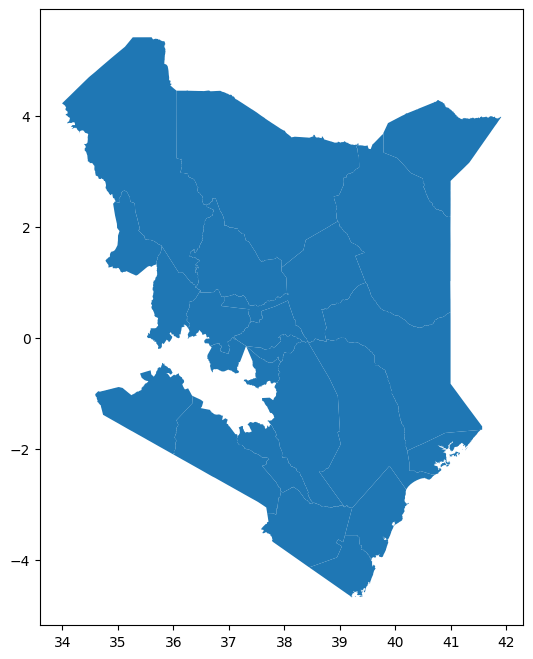

In [22]:
target_boundaries.plot(figsize=(8, 8))

## Boundary Processing Result

The Kenya county boundary file was successfully filtered from 47 counties to the 23 target counties used in the IPC analysis.

The processed boundary file was saved as `02_data/processed/kenya_target_counties.geojson`. This file will be used in later steps to join county-level food insecurity indicators with geographic boundaries and to calculate county-level rainfall averages from CHIRPS raster data.

## Calculate County-Level Rainfall from CHIRPS Raster

The CHIRPS rainfall file is a raster dataset, meaning rainfall values are stored as grid cells or pixels.

To use rainfall as a predictor in the food insecurity model, the raster values must be aggregated to county level.

This step calculates the average rainfall value for each of the 23 target counties.

In [23]:
from pathlib import Path

CHIRPS_FOLDER = Path("../02_data/raw/chirps")

list(CHIRPS_FOLDER.iterdir())

[WindowsPath('../02_data/raw/chirps/chirps-v2.0.2020.12.tif'),
 WindowsPath('../02_data/raw/chirps/chirps-v2.0.2020.12.tif.gz'),
 WindowsPath('../02_data/raw/chirps/chirps-v2.0.2022.12.tif'),
 WindowsPath('../02_data/raw/chirps/chirps-v2.0.2022.12.tif.gz'),
 WindowsPath('../02_data/raw/chirps/chirps-v2.0.2023.01.tif'),
 WindowsPath('../02_data/raw/chirps/chirps-v2.0.2023.01.tif.gz')]

In [24]:
rainfall_files = sorted(CHIRPS_FOLDER.glob("*.tif"))

rainfall_files

[WindowsPath('../02_data/raw/chirps/chirps-v2.0.2020.12.tif'),
 WindowsPath('../02_data/raw/chirps/chirps-v2.0.2022.12.tif'),
 WindowsPath('../02_data/raw/chirps/chirps-v2.0.2023.01.tif')]

In [25]:
print("Number of rainfall TIFF files:", len(rainfall_files))

Number of rainfall TIFF files: 3


In [26]:
import rasterio

sample_rainfall_path = rainfall_files[0]

with rasterio.open(sample_rainfall_path) as src:
    print("File:", sample_rainfall_path.name)
    print("CRS:", src.crs)
    print("Shape:", src.shape)
    print("Bounds:", src.bounds)
    print("No-data value:", src.nodata)

File: chirps-v2.0.2020.12.tif
CRS: EPSG:4326
Shape: (1600, 1500)
Bounds: BoundingBox(left=-20.0, bottom=-40.000001192092896, right=55.00000111758709, top=40.0)
No-data value: None


## Calculate Average Rainfall Per County

Now that the rainfall raster and county boundaries are ready, we calculate the average rainfall value inside each of the 23 target counties.

This turns pixel-level CHIRPS rainfall data into county-level rainfall data that can later be joined with the IPC food insecurity dataset.

In [27]:
print("Boundary CRS:", target_boundaries.crs)

with rasterio.open(sample_rainfall_path) as src:
    print("Raster CRS:", src.crs)

Boundary CRS: EPSG:4326
Raster CRS: EPSG:4326


In [28]:
import numpy as np
from rasterio.mask import mask

sample_results = []

with rasterio.open(sample_rainfall_path) as src:
    for _, row in target_boundaries.iterrows():
        county_name = row["county"]
        geometry = [row["geometry"]]

        out_image, out_transform = mask(src, geometry, crop=True)
        rainfall_values = out_image[0]

        # CHIRPS uses -9999 as no-data in this file
        rainfall_values = np.where(rainfall_values == -9999, np.nan, rainfall_values)

        mean_rainfall = np.nanmean(rainfall_values)

        sample_results.append({
            "county": county_name,
            "mean_rainfall_mm": mean_rainfall
        })

sample_rainfall_df = pd.DataFrame(sample_results)

sample_rainfall_df.sort_values("mean_rainfall_mm", ascending=False).head(10)

,county,mean_rainfall_mm
17,Taita Taveta,54.371876
6,Kitui,50.014824
7,Kwale,41.441311
10,Makueni,34.871555
5,Kilifi,33.413189
15,Nyeri,33.220531
13,Meru,32.953785
14,Narok,30.642649
18,Tana River,29.334854
4,Kajiado,26.549051


In [29]:
sample_rainfall_df.sort_values("county")

,county,mean_rainfall_mm
0,Baringo,7.767128
1,Embu,24.816837
2,Garissa,13.692744
3,Isiolo,12.284350
4,Kajiado,26.549051
5,Kilifi,33.413189
6,Kitui,50.014824
7,Kwale,41.441311
8,Laikipia,16.714722
9,Lamu,11.138682


In [30]:
from pathlib import Path
import pandas as pd

CHIRPS_FOLDER = Path("../02_data/raw/chirps")

rainfall_files = sorted(CHIRPS_FOLDER.glob("*.tif"))

print("Number of .tif files found:", len(rainfall_files))

available_months = [
    f.name.replace("chirps-v2.0.", "").replace(".tif", "")
    for f in rainfall_files
]

expected_months = pd.period_range(start="2019-01", end="2026-02", freq="M").strftime("%Y.%m").tolist()

missing_months = sorted(set(expected_months) - set(available_months))
extra_months = sorted(set(available_months) - set(expected_months))

print("Expected months:", len(expected_months))
print("Available months:", len(available_months))
print("Missing months:", missing_months)
print("Extra months:", extra_months)

Number of .tif files found: 86
Expected months: 86
Available months: 86
Missing months: []
Extra months: []


## CHIRPS Monthly File Coverage Check

The CHIRPS folder contains monthly rainfall `.tif` files from January 2019 to February 2026.

This period was selected because the IPC dataset covers current analysis periods from July 2019 to February 2026, and rainfall conditions before each IPC period may help explain later food insecurity outcomes.

The coverage check confirms that all expected monthly rainfall files are available for analysis.

## Process All CHIRPS Monthly Rainfall Files

The sample rainfall extraction worked for one file. This step repeats the same process for all 86 monthly CHIRPS files from January 2019 to February 2026.

The output will be a county-level rainfall dataset with one row per county per month.

In [31]:
import re
import numpy as np
import pandas as pd
import rasterio
from rasterio.mask import mask

all_rainfall_results = []

for rainfall_path in rainfall_files:
    # Extract year and month from file name, e.g. chirps-v2.0.2020.12.tif
    match = re.search(r"chirps-v2\.0\.(\d{4})\.(\d{2})\.tif", rainfall_path.name)
    
    if not match:
        print(f"Skipping file with unexpected name: {rainfall_path.name}")
        continue
    
    year = int(match.group(1))
    month = int(match.group(2))
    rainfall_date = pd.Timestamp(year=year, month=month, day=1)
    
    with rasterio.open(rainfall_path) as src:
        for _, row in target_boundaries.iterrows():
            county_name = row["county"]
            geometry = [row["geometry"]]
            
            out_image, out_transform = mask(src, geometry, crop=True)
            rainfall_values = out_image[0]
            
            # CHIRPS uses -9999 for missing/no-data values
            rainfall_values = np.where(rainfall_values == -9999, np.nan, rainfall_values)
            
            mean_rainfall = np.nanmean(rainfall_values)
            
            all_rainfall_results.append({
                "date": rainfall_date,
                "year": year,
                "month": month,
                "county": county_name,
                "mean_rainfall_mm": mean_rainfall,
                "source_file": rainfall_path.name
            })

county_rainfall = pd.DataFrame(all_rainfall_results)

print("County rainfall shape:", county_rainfall.shape)
county_rainfall.head()

County rainfall shape: (1978, 6)


,date,year,month,county,mean_rainfall_mm,source_file
0,2019-01-01,2019,1,Baringo,7.184619,chirps-v2.0.2019.01.tif
1,2019-01-01,2019,1,Embu,14.658785,chirps-v2.0.2019.01.tif
2,2019-01-01,2019,1,Garissa,4.258821,chirps-v2.0.2019.01.tif
3,2019-01-01,2019,1,Isiolo,4.558505,chirps-v2.0.2019.01.tif
4,2019-01-01,2019,1,Kajiado,8.523644,chirps-v2.0.2019.01.tif


In [32]:
county_rainfall.groupby("date")["county"].nunique().head()

date
2019-01-01    23
2019-02-01    23
2019-03-01    23
2019-04-01    23
2019-05-01    23
Name: county, dtype: int64

In [33]:
print("Number of months:", county_rainfall["date"].nunique())
print("Number of counties:", county_rainfall["county"].nunique())

Number of months: 86
Number of counties: 23


## Save County-Level Rainfall Dataset

The CHIRPS rainfall raster files were successfully aggregated to county level for all 86 months from January 2019 to February 2026.

The final rainfall dataset contains one row per county per month and will be saved as `county_rainfall.csv`.

This dataset can later be joined with the IPC food insecurity dataset to explore whether rainfall patterns help explain food insecurity severity.

In [34]:
COUNTY_RAINFALL_PATH = Path("../02_data/processed/county_rainfall.csv")

county_rainfall.to_csv(COUNTY_RAINFALL_PATH, index=False)

print(f"Saved county rainfall dataset to: {COUNTY_RAINFALL_PATH}")

Saved county rainfall dataset to: ..\02_data\processed\county_rainfall.csv


In [35]:
COUNTY_RAINFALL_PATH.exists()

True

## Rainfall Processing Result

The county-level rainfall dataset was successfully created and saved to `02_data/processed/county_rainfall.csv`.

The dataset contains 1,978 rows, representing 86 monthly rainfall periods across 23 target counties. This completes the rainfall data preparation stage.

The next stage will be to create rainfall features, such as 3-month and 6-month rainfall totals, and join them with the IPC food insecurity dataset.

## Create Rolling Rainfall Features

The county rainfall dataset contains monthly rainfall values. To make rainfall useful for food insecurity analysis, we create rolling rainfall features.

Rolling rainfall features summarize rainfall over the previous months. For example:
- 3-month rainfall total shows short-term rainfall conditions
- 6-month rainfall total shows seasonal rainfall conditions

These features can later be joined with IPC analysis periods to test whether rainfall deficits are linked with higher food insecurity severity.

In [36]:
county_rainfall = county_rainfall.sort_values(["county", "date"]).copy()

county_rainfall["rainfall_3_month_total"] = (
    county_rainfall
    .groupby("county")["mean_rainfall_mm"]
    .rolling(window=3, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

county_rainfall["rainfall_6_month_total"] = (
    county_rainfall
    .groupby("county")["mean_rainfall_mm"]
    .rolling(window=6, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

county_rainfall["rainfall_3_month_avg"] = (
    county_rainfall
    .groupby("county")["mean_rainfall_mm"]
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

county_rainfall["rainfall_6_month_avg"] = (
    county_rainfall
    .groupby("county")["mean_rainfall_mm"]
    .rolling(window=6, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

county_rainfall.head(10)

,date,year,month,county,mean_rainfall_mm,source_file,rainfall_3_month_total,rainfall_6_month_total,rainfall_3_month_avg,rainfall_6_month_avg
0,2019-01-01,2019,1,Baringo,7.184619,chirps-v2.0.2019.01.tif,7.184619,7.184619,7.184619,7.184619
23,2019-02-01,2019,2,Baringo,4.409290,chirps-v2.0.2019.02.tif,11.593909,11.593909,5.796955,5.796955
46,2019-03-01,2019,3,Baringo,17.688416,chirps-v2.0.2019.03.tif,29.282325,29.282325,9.760775,9.760775
69,2019-04-01,2019,4,Baringo,40.918781,chirps-v2.0.2019.04.tif,63.016487,70.201106,21.005496,17.550277
92,2019-05-01,2019,5,Baringo,29.830008,chirps-v2.0.2019.05.tif,88.437204,100.031114,29.479068,20.006223
115,2019-06-01,2019,6,Baringo,72.692665,chirps-v2.0.2019.06.tif,143.441454,172.723779,47.813818,28.787296
138,2019-07-01,2019,7,Baringo,64.745667,chirps-v2.0.2019.07.tif,167.268339,230.284826,55.756113,38.380804
161,2019-08-01,2019,8,Baringo,70.052521,chirps-v2.0.2019.08.tif,207.490852,295.928057,69.163617,49.321343
184,2019-09-01,2019,9,Baringo,32.347832,chirps-v2.0.2019.09.tif,167.146019,310.587473,55.715340,51.764579
207,2019-10-01,2019,10,Baringo,63.260471,chirps-v2.0.2019.10.tif,165.660824,332.929163,55.220275,55.488194


## Save Rainfall Feature Dataset

The monthly county rainfall data has been converted into rolling rainfall features. These features summarize rainfall over 3-month and 6-month windows and will be used later to compare rainfall conditions with IPC food insecurity outcomes.

In [38]:
RAINFALL_FEATURES_PATH = Path("../02_data/processed/county_rainfall_features.csv")

county_rainfall.to_csv(RAINFALL_FEATURES_PATH, index=False)

print(f"Saved rainfall feature dataset to: {RAINFALL_FEATURES_PATH}")

Saved rainfall feature dataset to: ..\02_data\processed\county_rainfall_features.csv


In [39]:
RAINFALL_FEATURES_PATH.exists()

True

## Rainfall Feature Engineering Result

The rainfall feature dataset was successfully created and saved as `02_data/processed/county_rainfall_features.csv`.

The dataset contains monthly rainfall values for each target county, plus 3-month and 6-month rolling rainfall totals and averages.

These features will be used in the next stage to join rainfall conditions with IPC food insecurity outcomes.